Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
import joblib

Load Dataset

In [4]:
df = pd.read_csv("../datasets/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Basic EDA

In [3]:
df.shape

(1025, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(723)

Remove Duplicate Data

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(302, 14)

In [10]:
print(df["target"].value_counts())

target
1    164
0    138
Name: count, dtype: int64


In [11]:
print(df["sex"].unique())

[1 0]


In [36]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()
df.shape
print(df["target"].value_counts())
print(df["sex"].unique())

<class 'pandas.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB
target
1    164
0    138
Name: count, dtype: int64
[1 0]


Detailed EDA

Target Distribution

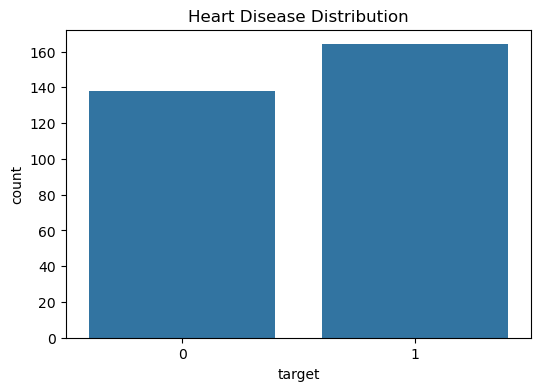

target
1    164
0    138
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

print(df["target"].value_counts())

Univariate Analysis (Numerical Features)

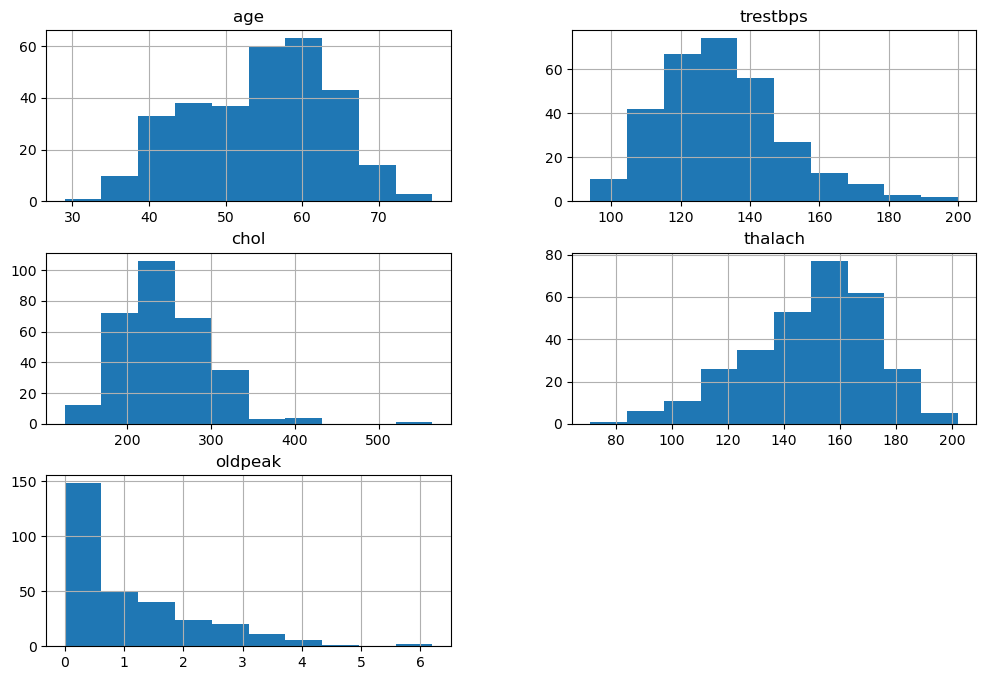

In [13]:
num_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

df[num_cols].hist(figsize=(12,8))
plt.show()

Univariate Analysis (Categorical Features)

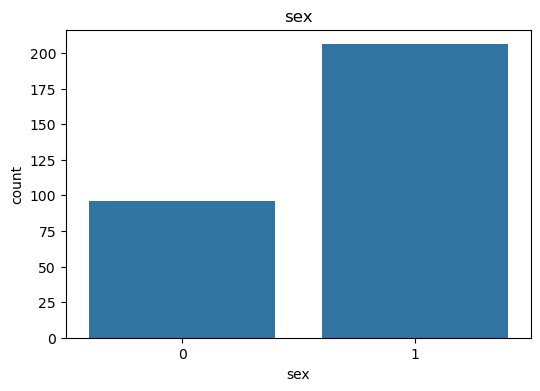

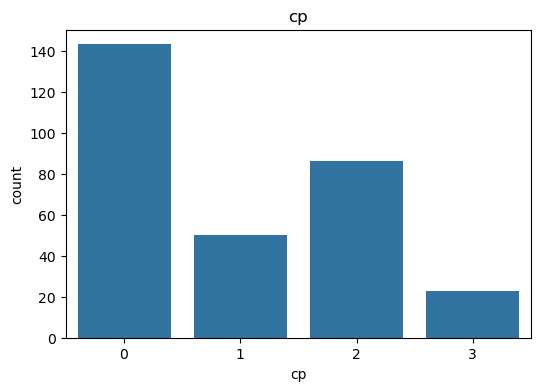

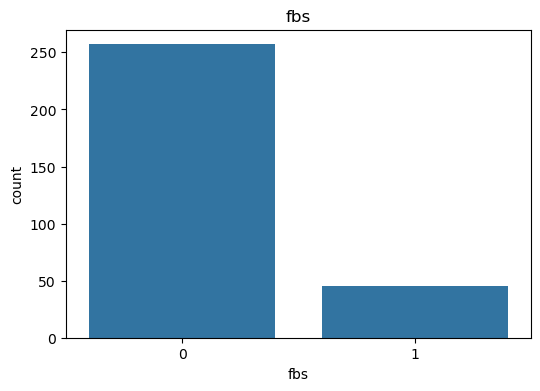

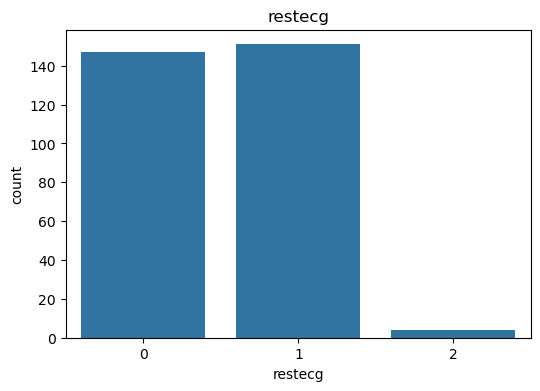

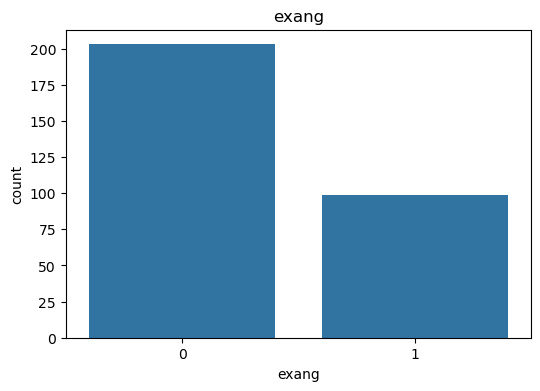

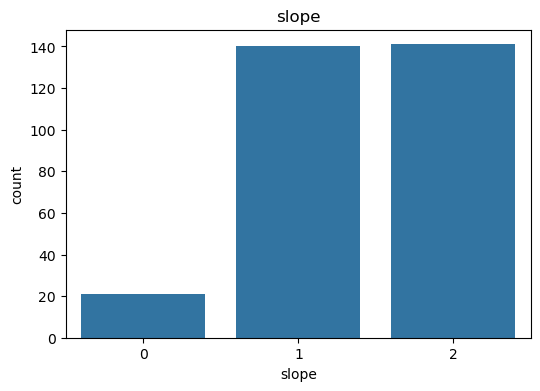

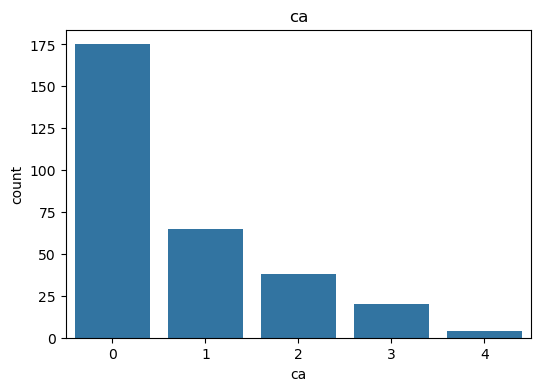

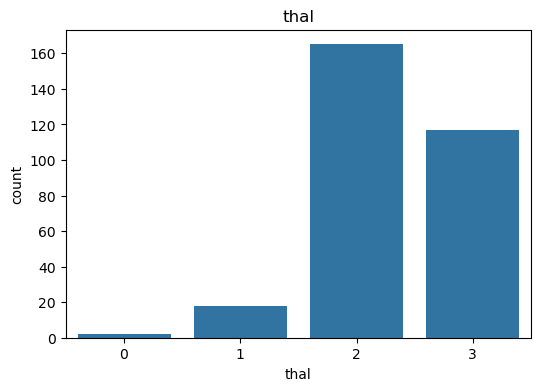

In [14]:
cat_cols = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

Correlation Heatmap

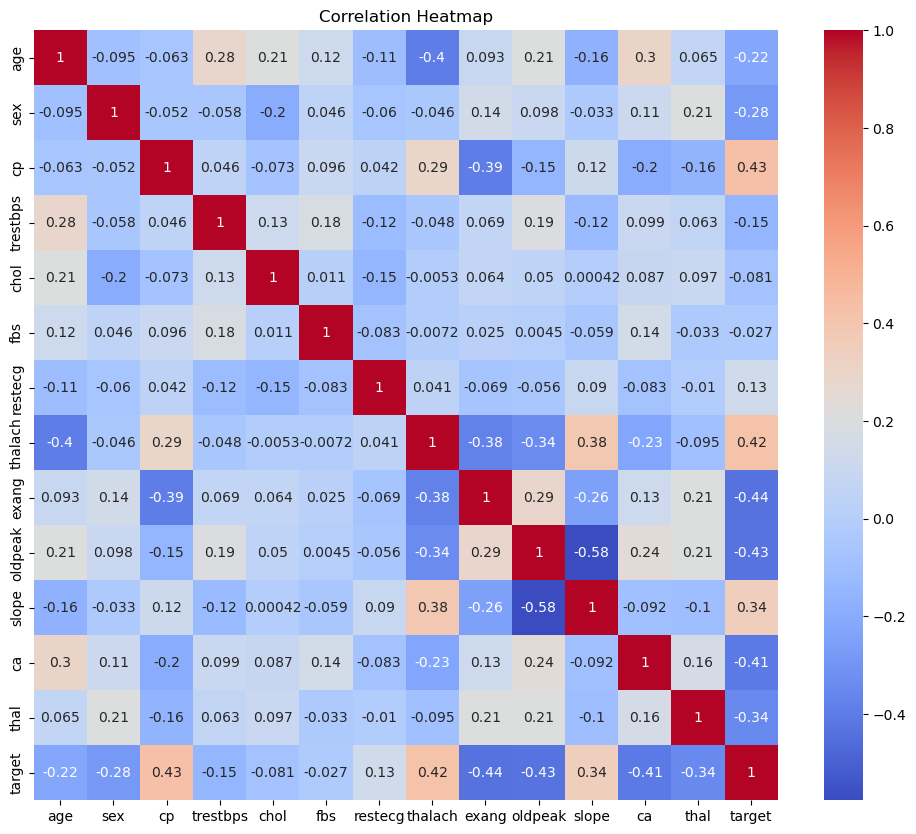

In [15]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Outlier Detection

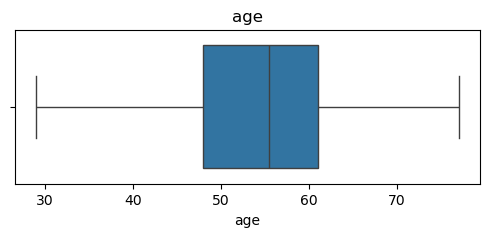

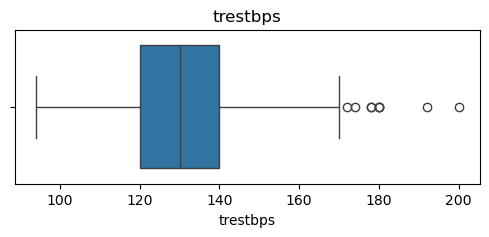

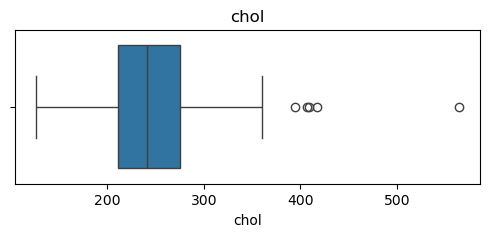

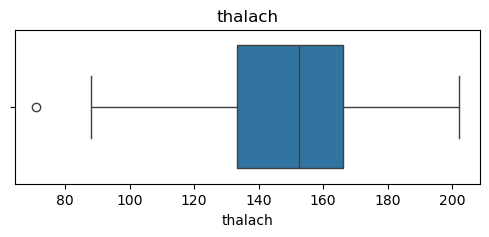

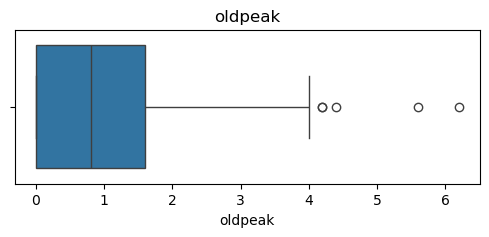

In [16]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Feature vs Target Analysis (Numerical)

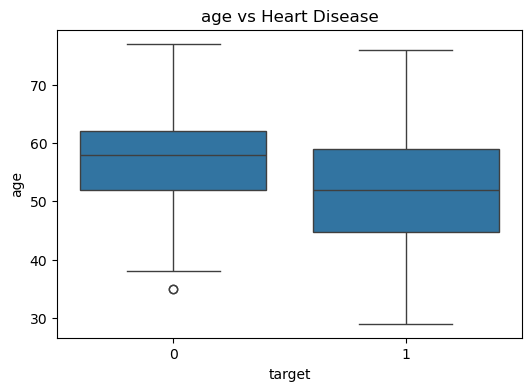

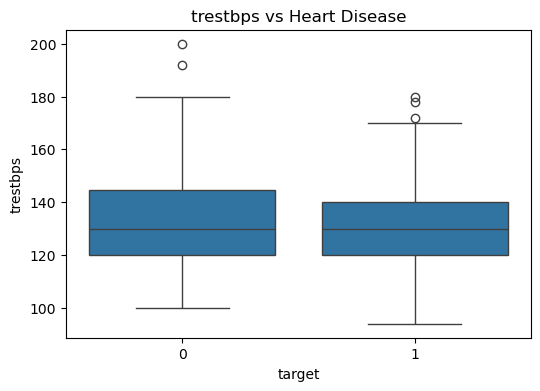

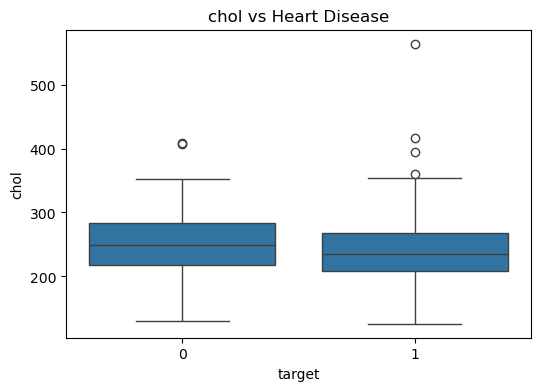

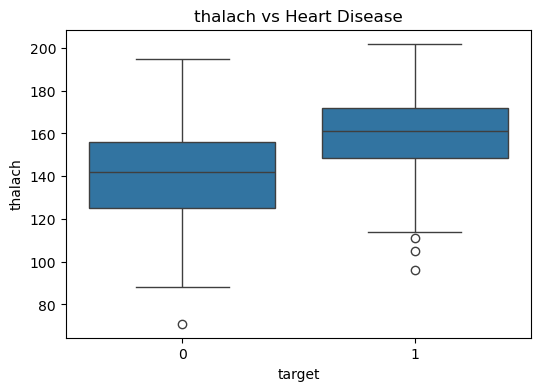

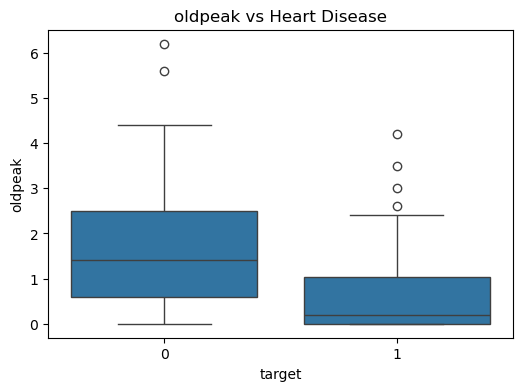

In [17]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()

Feature vs Target Analysis (Categorical)

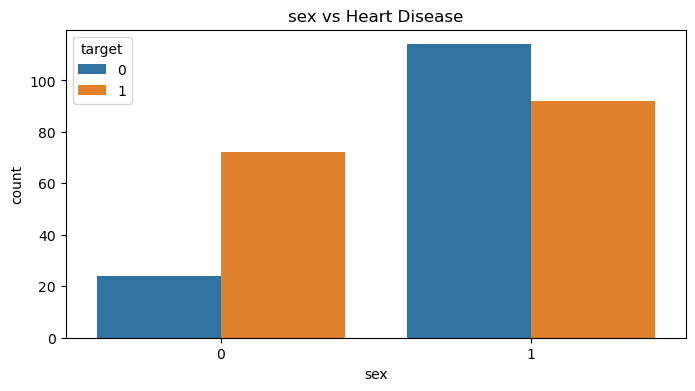

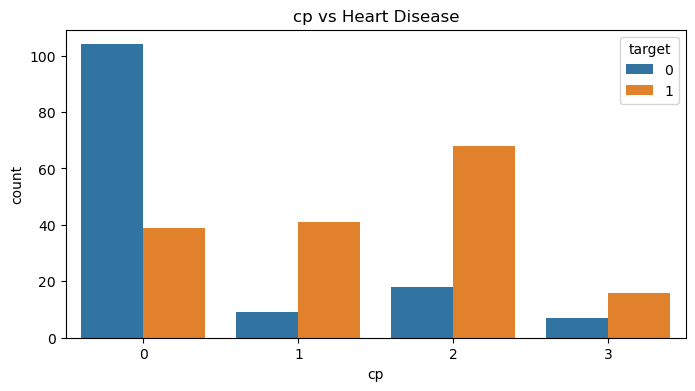

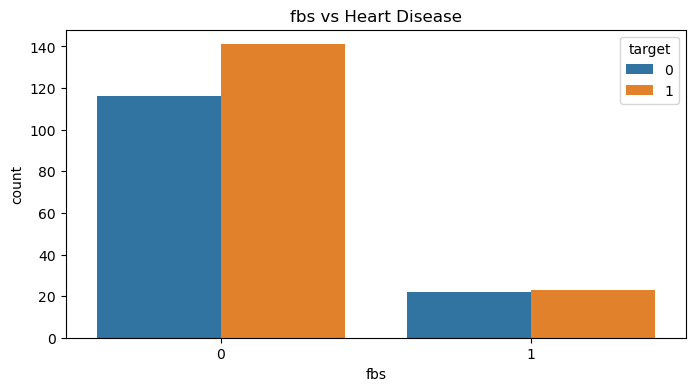

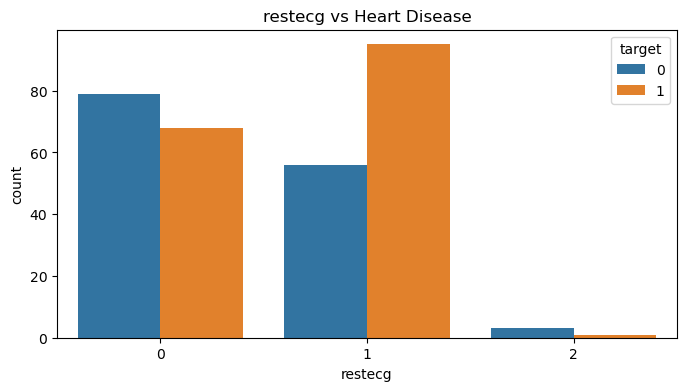

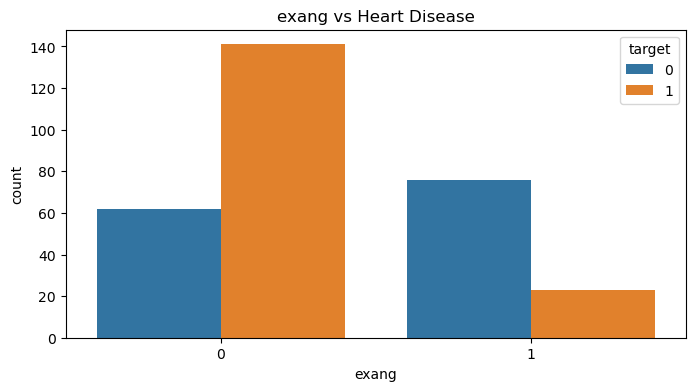

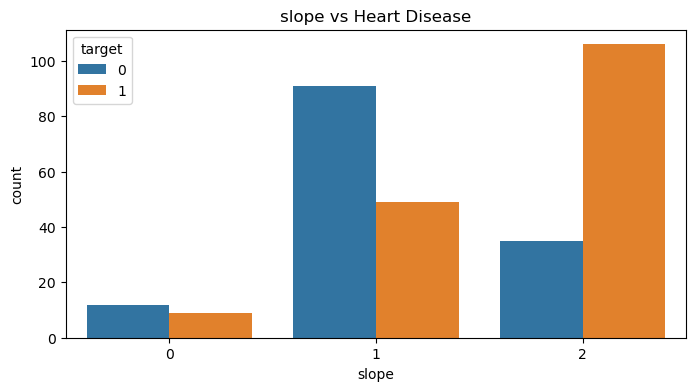

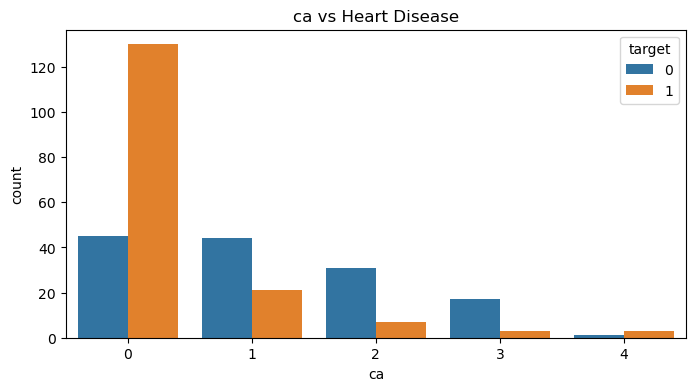

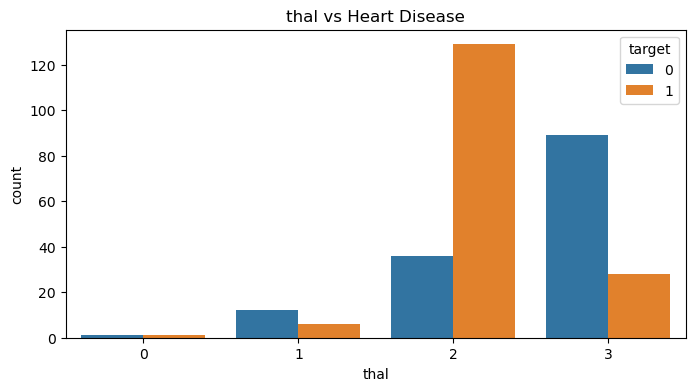

In [18]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue="target", data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()

Separate Features and Target

In [19]:
X = df.drop("target", axis=1)
y = df["target"]

Train Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Find Numerical & Categorical Columns

In [21]:
num_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

cat_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

Preprocessing Pipeline

In [22]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

Transform Data

In [23]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(241, 30)
(61, 30)


Create Model Dictionary

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

Train Every Model

In [25]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_processed)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc
    })

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training XGBoost...


Compare Models

In [26]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.836066,0.848485,0.848485,0.848485,0.904762
3,KNN,0.836066,0.870968,0.818182,0.843750,0.886364
2,Random Forest,0.803279,0.818182,0.818182,0.818182,0.884199
4,XGBoost,0.721311,0.735294,0.757576,0.746269,0.829004
1,Decision Tree,0.737705,0.774194,0.727273,0.750000,0.738636


Select Best Model

In [27]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


Cross Validation

In [28]:
from sklearn.model_selection import cross_val_score

best_model = models[best_model_name]

cv_scores = cross_val_score(
    best_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores :", cv_scores)
print("Mean CV Accuracy :", cv_scores.mean())
print("Standard Deviation :", cv_scores.std())

Cross Validation Scores : [0.85714286 0.77083333 0.8125     0.875      0.85416667]
Mean CV Accuracy : 0.8339285714285716
Standard Deviation : 0.03761791740315465


Check Overfitting

In [29]:
train_pred = models[best_model_name].predict(X_train_processed)
test_pred = models[best_model_name].predict(X_test_processed)

print("Train Accuracy :", accuracy_score(y_train, train_pred))
print("Test Accuracy  :", accuracy_score(y_test, test_pred))

Train Accuracy : 0.8838174273858921
Test Accuracy  : 0.8360655737704918


Classification Report

In [30]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



Confusion Matrix

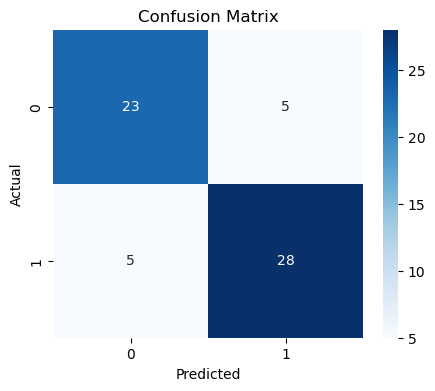

In [31]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Save Best Model

In [ ]:
joblib.dump(
    models[best_model_name],
    "../models/heart_model.pkl"
)

joblib.dump(
    preprocessor,
    "../models/heart_preprocessor.pkl"
)

'joblib.dump(\n    models[best_model_name],\n    "../models/heart_model.pkl"\n)\n\njoblib.dump(\n    preprocessor,\n    "../models/heart_preprocessor.pkl"\n)'

In [5]:
df.groupby('target')[['age','chol','thalach','oldpeak']].mean()

,age,chol,thalach,oldpeak
target,,,,
0,56.569138,251.292585,139.130261,1.600200
1,52.408745,240.979087,158.585551,0.569962


In [34]:
print(df["target"].value_counts())

print(df.groupby("target")["thalach"].mean())

print(df.groupby("target")["oldpeak"].mean())

target
1    164
0    138
Name: count, dtype: int64
target
0    139.101449
1    158.378049
Name: thalach, dtype: float64
target
0    1.585507
1    0.586585
Name: oldpeak, dtype: float64


In [35]:
import pandas as pd

sample = X_test.iloc[:20]

sample_processed = preprocessor.transform(sample)

pred = best_model.predict(sample_processed)

comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": pred
})

print(comparison)

    Actual  Predicted
0        0          0
1        0          1
2        0          0
3        0          1
4        0          1
5        0          0
6        1          1
7        0          0
8        1          1
9        0          0
10       1          1
11       1          1
12       0          1
13       1          1
14       1          0
15       1          1
16       1          1
17       1          0
18       1          1
19       1          1
